# Examples of burgers equation discovery with EPDE framework

This notebook presents an overview of the evolutionary discovery of the burgers equation with the EPDE framework.


In [13]:
import numpy as np
import pandas as pd
import os
import sys
from typing import Union, Callable

import matplotlib.pyplot as plt
import matplotlib as mpl

Add some necessary imports

In [14]:
import sys
sys.path.append('..')

In [15]:
import epde

In [16]:
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['text.usetex'] = False

SMALL_SIZE = 12
mpl.rc('font', size=SMALL_SIZE)
mpl.rc('axes', titlesize=SMALL_SIZE)

# Burgers equation introduction

Burgers equation — a compact model that combines two of the most important effects in fluid dynamics in a single one-dimensional partial differential equation:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, \tag{1}
$$

where:

- $u(x, t)$ — the unknown field (commonly interpreted as the velocity of a fluid particle at position $x$ and time $t$);
- $t$ — time;
- $x$ — spatial coordinate;
- $\nu$ — the viscosity coefficient, controlling how strongly the diffusion term smooths the solution.



**Where it comes from.** The equation was first written down by Harry Bateman in 1915 as a mathematical curiosity, but it is named after Johannes Martinus Burgers.

**Example solution.** To generate data we will use an analytical particular solution corresponding to a step initial condition (a Riemann problem):

$$
u(x, 0) = \begin{cases} u_L, & x < 0 \\ u_R, & x > 0 \end{cases}, \quad u_L > u_R. \tag{2}
$$

Seeking a traveling-wave solution $u(x,t) = f(x - st)$ and integrating the resulting ODE we achieve a result:

$$
u(x,t) = 0.5 - 0.5\tanh\big[2.5(x - 0.5t)\big]. \tag{4}
$$

The profile is a smooth S-shaped front connecting $u_L$ and $u_R$, translating along $x$ at constant speed $s$ without changing shape — a stationary balance between nonlinear steepening and viscous smoothing.

You can see illustration of this equation solution below

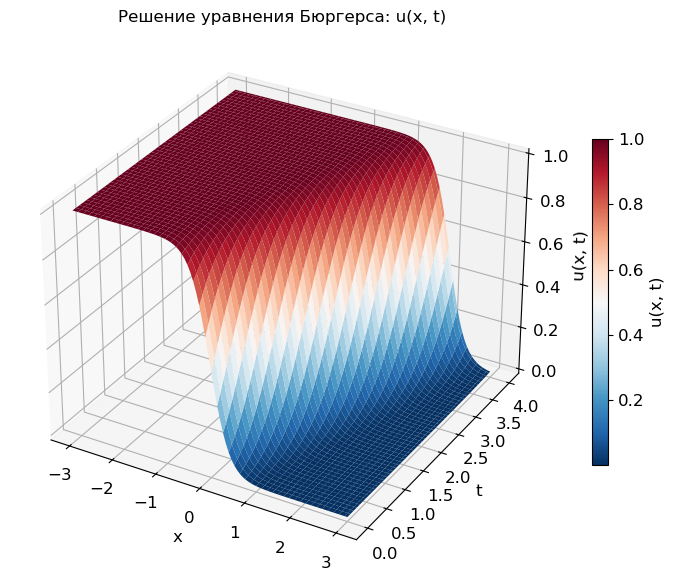

In [43]:
from mpl_toolkits.mplot3d import Axes3D  # нужен для projection='3d'

nu = 0.1
uL, uR = 1.0, 0.0
s = (uL + uR) / 2

t = np.linspace(0, 4, 100)
x = np.linspace(-3, 3, 100)
T, X = np.meshgrid(t, x, indexing='ij')

U = s - (uL - uR) / 2 * np.tanh((uL - uR) * (X - s * T) / (4 * nu))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, T, U, cmap='RdBu_r', edgecolor='none', antialiased=True)

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x, t)')
ax.set_title('Решение уравнения Бюргерса: u(x, t)')
fig.colorbar(surf, shrink=0.6, label='u(x, t)')
fig.tight_layout()
plt.show()

To illustrate results of EPDE algorithm we will use two dimensional grid(t, x) with 10201 points, t in segment [0, 1], x in segment [-1000, 0]. Target variable u we will take from the .csv file

In [44]:

file_directory = '../projects/pic/data/burgers/burgers_sln_100.csv'
df = pd.read_csv(file_directory, header = None)
u = df.values
data = np.transpose(u)
t = np.linspace(0, 1, 101)
x = np.linspace(-1000, 0, 101)
grid = np.meshgrid(t, x, indexing = 'ij')  # np.stack(, axis = 2) , axis = 2)
grid

(array([[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
        [0.02, 0.02, 0.02, ..., 0.02, 0.02, 0.02],
        ...,
        [0.98, 0.98, 0.98, ..., 0.98, 0.98, 0.98],
        [0.99, 0.99, 0.99, ..., 0.99, 0.99, 0.99],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]], shape=(101, 101)),
 array([[-1000.,  -990.,  -980., ...,   -20.,   -10.,     0.],
        [-1000.,  -990.,  -980., ...,   -20.,   -10.,     0.],
        [-1000.,  -990.,  -980., ...,   -20.,   -10.,     0.],
        ...,
        [-1000.,  -990.,  -980., ...,   -20.,   -10.,     0.],
        [-1000.,  -990.,  -980., ...,   -20.,   -10.,     0.],
        [-1000.,  -990.,  -980., ...,   -20.,   -10.,     0.]],
       shape=(101, 101)))

After that we shall initialize equation search object

In [45]:
from epde.interface.interface import EpdeSearch
epde_search_obj = EpdeSearch(use_solver=False, multiobjective_mode=True,
                              use_pic=True, boundary=20,
                              coordinate_tensors=grid, device='cuda',
                              memory_for_cache=5)
         
# print(grid)

setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x000001B8395CB9D0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x000001B8395CB9D0>


Here you can see the explanation of each parametr in EpdeSearch creation:
   -  ``use_solver = False`` — skip the automatic PDE solver when scoring candidate equations; faster, less precise fitness estimate
   - ``multiobjective_mode = True`` — run MOEADD multi-objective search: Pareto front by Discrepancy (quality) + Instability
   - ``use_pic = True`` — define second pareto axis = Instability
   - ``boundary = 20`` — ignore this many grid points from each edge of the domain when computing derivatives
   - ``coordinate_tensors = grid`` — grid coordinate tensors (from np.meshgrid) matching the data array
   - ``device = 'cpu'`` — device for torch computations

In [46]:
epde_search_obj.set_preprocessor(default_preprocessor_type='FD',
                                     preprocessor_kwargs={})
popsize = 16

epde_search_obj.set_moeadd_params(population_size=popsize,
                                      training_epochs = 12)


In the cell above we define data preprocessor settings( preprocessing without data smoothing, finite derive calculation).
Additional parameters will be population size and number of optimziation epochs: ``training_epochs = 2``.

In [ ]:
factors_max_number = {'factors_num': [1, 2], 'probas': [0.65, 0.35]}

epde_search_obj.fit(data = data, variable_names=['u', ], max_deriv_order=(2, 3), derivs=None,
                    equation_terms_max_number=5, data_fun_pow=3,
                    additional_tokens=[],
                    equation_factors_max_number=factors_max_number,
                    fourier_layers=False)


Deriv orders after definition [[0], [0, 0], [1], [1, 1], [1, 1, 1]]
initial_shape (3721,) derivs_tensor.shape (3721, 5)
Size of linked labels is 6
The cardinality of defined token pool is [1 5]
Among them, the pool contains [1 5]
self.vars_demand_equation {'u'}
best_obj 2

========== Initial population ==========
[0.10156056 0.890134  ]
[0.24487883 2.6289133 ]
[ 0.35587184 30.96853011]
[0.02651188 0.0187043 ]
[0.071986   0.13580983]
[0.005414   0.00747633]
[0.10382534 1.68784764]
[3.05695936e-05 7.51000812e-08]
[0.19693332 2.30025222]
[0.39315897 2.54200121]
[ 0.31715201 24.18890496]
[0.22649661 1.80981806]
[0.03130768 0.01788788]
[0.38023562 2.10508404]
[0.2503106  2.06950592]
[0.20716789 6.52239967]

========== Marriage (weight assignment) ==========
acute_angles
 [[1.13604550e-01 9.28802985e-02 1.14908965e-02 9.56384386e-01
  4.87397638e-01 6.26751699e-01 6.14360431e-02 1.56833964e+00
  8.54055355e-02 1.53449278e-01 1.31107151e-02 1.24501529e-01
  1.05170378e+00 1.78700473e-01 1.203

Here you can see the explanation of each parametr in fit method:
 - argument ``data`` desctibes array of target variable(u)
 - argument ``variable_names`` sets name of target variable
 - argument ``max_deriv_order`` sets the highest order of derivatives, that can be used in equation search
- number of terms, accepted into the structure before regularization is regulated by argument ``equation_terms_max_number``
- argument ``equation_factors_max_number`` defines number of terms in the term can be set as integer (in this case, the number of factors for the particular term is selected from a uniform distribution
- argeument ``derives = None``  means that algorithm calculates derivatives in the method, skips pre-computed values 
- argument ``additional_tokens`` sets tokens, hat would be used to construct the equations among the main variables and their derivatives
- argument ``data_fun_pow`` describes maximum power of token


The discovered equations can be accessed with ``EpdeSearch.equations()`` method. If the ``only_print = True``, than the equations will be printed in their text forms. 

Otherwise, they will be return: if the followup argument ``only_str`` is ``True``, than the equations are returned only in their symbolic string-form. If ``only_str = False``, than the equation in its program implementation ``epde.structure.main_structures.SoEq`` are returned.

Additional parametr ``num = 5`` define number of poretto-levels for printing

In [ ]:
epde_search_obj.equations(only_print=True, num = 5)



0-th non-dominated level


-1.0000000073893758 * u{power: 1.0} * du/dx1{power: 1.0} + -4.998473288999407e-05 * du/dx1{power: 1.0} * d^2u/dx0^2{power: 1.0} + 0.0 = du/dx0{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 5}, 'max_factors_in_term': {'optimizable': False, 'value': {'factors_num': [1, 2], 'probas': [0.65, 0.35]}}, ('sparsity', 'u'): {'optimizable': True, 'value': np.float64(0.012821869138330076)}} , with objective function values of [3.01977637e-10 0.00000000e+00] 



1-th non-dominated level


-0.0004266097316171656 * d^2u/dx0^2{power: 1.0} * du/dx1{power: 1.0} + -1.9997003520599899 * du/dx0{power: 1.0} * du/dx1{power: 1.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 5}, 'max_factors_in_term': {'optimizable': False, 'value': {'factors_num': [1, 2], 'probas': [0.65, 0.35]}}, ('sparsity', 'u'): {'optimizable': True, 'value': np.float64(0.012821869138330076)}} , with objective function values of [1.53384261e-06 3.84155

In [ ]:
res = epde_search_obj.equations(False)

[[<epde.structure.main_structures.SoEq at 0x1b83b239650>]]

## Resulting Equation

As a result of running EPDE, the following equation was obtained:

$$\frac{\partial u}{\partial t} = -1.0000000073893764\cdot u\cdot\frac{\partial u}{\partial x} \;-\; 4.998473288943103\times10^{-5}\cdot\frac{\partial^2 u}{\partial t^2}\cdot\frac{\partial u}{\partial x}$$

Comparing this with the classical Burgers' equation

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}$$

reveals the following:

- The **convective term** ($u\,u_x$) is reproduced almost exactly: the coefficient deviates from the reference value of $-1$ by only $\sim7\times10^{-9}$.
- The **diffusive term** matches less well: instead of a pure second derivative $u_{xx}$, the algorithm found a product of $u_{tt}\cdot u_x$, meaning its structure differs from what was expected.
- However, the coefficient of this term is very small ($\approx 5\times10^{-5}$), so its contribution to the equation is negligible, keeping the overall error small.

Overall, the discovered equation can be considered a good approximation of the inviscid Burgers' equation.

We can use visual analysis of the Pareto-optimal set of candidate equations, placed in the complexity-quality criteria space, to select the optimal equation. Method ``EpdeSearch.visualize_solutions()`` illustrates the first non-dominated set of solutions (i.e. Pareto frontier).

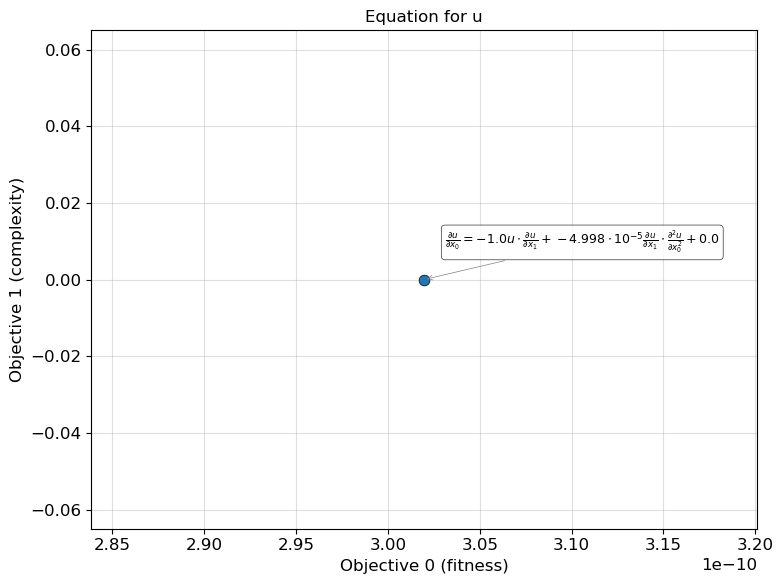

[<Figure size 800x600 with 1 Axes>]

In [ ]:
epde_search_obj.visualize_solutions()

We can see only one equation, because data is clear and this equation overcome each other